# GSD²T Asset Management — Quant Appendix
### ESADE Asset Management · Group Project · Live pitch 10 June 2026

**Strategy:** Macro-Overlay Equity Momentum (long-only) with a defensive Treasuries-and-gold sleeve — the **V1** flagship.

> ⚠️ **All performance in this notebook is SIMULATED** on historical data (2002–2026), **net of 15 bps trading costs** and **gross of fund fees** (a separate net-of-fee section deducts the stated fees). **No live or paper track record exists** — the fund is fictional. Past simulated performance does not indicate future results.

**AI-tool disclosure:** AI assistants were used for code scaffolding, backtest engineering and drafting. All strategy decisions, data choices and results were defined and verified by the team; nothing was fabricated.

**What is recomputed live vs loaded:** the headline backtest, risk metrics, factor regression, stress tests and capacity (§4–§7, §11) are **recomputed live** when you run the cells. The survivorship correction (§8), the concentration study (§10) and the assumption stress-tests (§9) **load committed JSON artefacts** produced by `survivorship_corrected.py`, `concentration_*.py` and `robustness_assumptions.py` — the Bloomberg point-in-time data is heavy, so those run separately and are fully reproducible from the repo (the `json.load(...)` calls make this explicit in-cell).

### What the brief requires, and where it is

| Spec requirement | Section |
|---|---|
| CAGR, volatility, Sharpe | §5 Headline results |
| Maximum drawdown | §5 (table) + §6 (chart) |
| Turnover | §5 (≈379%/yr) |
| At least one stress scenario | §7 (seven crisis windows) |
| Data sources documented | §1 Data sources |
| Look-ahead controls documented | §2 Look-ahead controls |
| Simulated vs live, clearly labelled | banner above, plus every printed result is tagged **SIMULATED** |

Everything below is **SIMULATED** on historical data. **No live or paper track record exists.**

## 0 · Setup

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, statsmodels.api as sm
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize":(10,5),"font.size":11})

CACHE=Path("data_cache"); DATA_ROOT=Path("course_data")
TC_BPS=15                       # round-trip trading cost (stress-tested later)
START="2002-01-31"              # performance measured from 2002 (2000-01 reserved as signal warm-up)
IS_END="2015-12-31"; OOS_START="2016-01-31"
def me(idx): return pd.to_datetime(idx).to_period("M").to_timestamp("M")
print("Setup complete · all results SIMULATED · window from", START)

Setup complete · all results SIMULATED · window from 2002-01-31


## 1 · Data sources

| Data | Source | Used for |
|---|---|---|
| S&P 500 stock prices (monthly, total-return adj.) | yfinance | Momentum signal, stock returns |
| VIX, IEF, HYG, 10Y yield (^TNX), S&P 500 (^GSPC) | yfinance | The 4-factor macro overlay |
| Defensive sleeve: TLT, GLD (IEF early fallback) | yfinance | Risk-off sleeve |
| Fama-French 5 factors + Momentum, risk-free rate | Ken French Data Library (vintage through 2026-04) | Alpha / factor regression, Sharpe |
| Point-in-time S&P 500 membership + total returns | Bloomberg | Survivorship-bias correction |
| S&P 500 membership | Published index membership (current); **Bloomberg point-in-time** for the survivorship test | Universe definition |

All market data is cached in `data_cache/`; factor data in `course_data/`. The notebook runs fully offline.

In [2]:
prices=pd.read_csv(CACHE/"prices_sp500_monthly.csv",index_col=0,parse_dates=True)
bench=pd.read_csv(CACHE/"prices_benchmarks_monthly.csv",index_col=0,parse_dates=True)
vix=pd.read_csv(CACHE/"prices_vix_monthly.csv",index_col=0,parse_dates=True); vix.columns=["VIX"]
macro_px=pd.read_csv(CACHE/"macro_proxies_monthly.csv",index_col=0,parse_dates=True)
cons=pd.read_csv(CACHE/"sp500_constituents.csv")
defv=pd.read_csv(CACHE/"defensive_monthly.csv",index_col=0,parse_dates=True)
for df in (prices,bench,vix,macro_px,defv): df.index=me(df.index)
universe=[t for t in cons["ticker"] if t in prices.columns]
returns=prices[universe].pct_change(); spy=bench["SPY"].pct_change()
print(f"Loaded {len(universe)} stocks across {len(prices)} months: {prices.index.min():%Y-%m} to {prices.index.max():%Y-%m}")

Loaded 503 stocks across 317 months: 2000-01 to 2026-05


## 2 · Look-ahead controls (data hygiene)

Every signal uses **only information available at decision time**:

- **Momentum** is computed from *past* returns and **shifted one month** (`.shift(1)`) — we never use the current month's return to trade the current month.
- **Macro-overlay z-scores** use **trailing rolling windows only** (60-month mean/SD, min 24) — no future data enters the standardisation.
- The **composite overlay score is lagged one month** before it sets exposure.
- **Portfolio weights are lagged** (`wL.shift(1)`) before being multiplied by returns — positions are formed at month *t*, returns earned at *t+1*.
- **2000–2001 is reserved as warm-up** so signals are fully formed; performance is measured from **2002**.
- **Factor availability (disclosed):** the credit factor is built from the HYG high-yield ETF (inception 2007), so it joins the overlay around **2010**; before then the dial runs on the other three factors (VIX, yield, trend). This is data availability, not look-ahead — the overlay uses only the factors that existed at each point in time, and the result is robust to it (Sharpe 1.09 from 2002 vs 1.07 from 2004).
- **Universe construction (disclosed, and tested directly — not haircut):** the *headline* backtest in §5 applies **today's** S&P 500 membership across the whole 2002–2026 window (a 2015 joiner is traded from 2002), because the point-in-time data we hold is quarterly total returns, not monthly prices for the full strategy. So the headline carries survivorship at the universe level. Rather than apply an arbitrary haircut to the headline, we **measure the bias directly**: §8 runs a matched engine on Bloomberg **point-in-time** membership versus survivors-only, and the gap is **small — ~1%/yr of CAGR, ~0.10 of Sharpe**. That direct point-in-time test, not a fudge factor, is our survivorship control. The *signals* are still strictly lagged as above.
- **Survivorship test:** the §8 section uses Bloomberg **point-in-time** membership, not today's constituents.

## 3 · Signals — momentum + the 4-factor macro overlay

In [3]:
def rz(s,w=60,mp=24):  # trailing rolling z-score (no look-ahead)
    return (s-s.rolling(w,min_periods=mp).mean())/s.rolling(w,min_periods=mp).std()
def momentum(r,lb=12,sk=1):  # 12-1 momentum, lagged
    return np.log1p(r).shift(sk).rolling(lb-sk).sum()
def zcs(p):  # cross-sectional z-score (compare each stock to the others, each month)
    return p.sub(p.mean(axis=1),axis=0).div(p.std(axis=1),axis=0)

idx=vix.index; c=pd.DataFrame(index=idx)
c["VIX (fear)"]=-rz(vix["VIX"])
cred=np.log(macro_px["IEF"]).reindex(idx).ffill()-np.log(macro_px["HYG"]).reindex(idx).ffill()
c["Credit stress"]=-rz(cred.diff(12))
c["Rate change"]=-rz(macro_px["^TNX"].reindex(idx).ffill().diff(12))
spx=macro_px["^GSPC"].reindex(idx).ffill(); c["Market trend"]=rz(np.log(spx).diff(1).shift(1).rolling(11).sum())
score=c.mean(axis=1).clip(-2,2).shift(1)              # equal-weight average, clipped, LAGGED
gross=np.clip(0.65+0.175*score,0.3,1.0)               # map score -> 30%-100% equity exposure
print("4 overlay factors (equal-weighted), latest readings:")
c.dropna().tail(3).round(2)

4 overlay factors (equal-weighted), latest readings:


,VIX (fear),Credit stress,Rate change,Market trend
Date,,,,
2026-03-31,-1.25,-0.80,1.08,0.61
2026-04-30,0.40,-0.17,1.05,0.31
2026-05-31,0.71,-0.77,1.02,0.62


## 4 · Strategy engine — V1 (select → overlay → defensive sleeve)

In [4]:
# risk-free rate (Ken French), loaded here so the defensive sleeve earns RF on early missing data,
# matching the canonical flagship engine (build_v1_flagship.py) exactly.
def load_ff():
    ff5=pd.read_csv(DATA_ROOT/"Folder_Macro_Factors_.187814089"/"content"/"F-F_Research_Data_5_Factors_2x3_daily.CSV",skiprows=3,index_col=0)
    ff5.columns=[x.strip() for x in ff5.columns]; ff5.index=pd.to_datetime(ff5.index.astype(str),format="%Y%m%d"); ff5/=100.0
    mom=pd.read_csv(DATA_ROOT/"Folder_Macro_Factors_.187814089"/"content"/"F-F_Momentum_Factor_daily.CSV",skiprows=13,index_col=0,skipfooter=2,engine="python")
    mom.columns=["Mom"]; mom=mom.dropna(); mom.index=pd.to_datetime(mom.index.astype(str).str.strip(),format="%Y%m%d",errors="coerce"); mom=mom.dropna()/100.0
    m=(1+ff5.join(mom,how="inner")).resample("ME").prod()-1; m.index=me(m.index); return m
ff=load_ff(); rf=ff["RF"]

# defensive sleeve return: Treasuries + gold (IEF as early fallback); missing data earns RF, not 0 (flagship convention)
dret=defv.pct_change(); ief_ret=macro_px["IEF"].pct_change()
defensive_ret=dret.mean(axis=1).reindex(returns.index).fillna(ief_ret).fillna(rf)

# Layer 1 — selection: top-quartile momentum, equal weight
sig=zcs(momentum(returns)); mask=(sig.rank(axis=1,pct=True)>=0.75).astype(float)
w=mask.div(mask.sum(axis=1).replace(0,np.nan),axis=0).fillna(0)
# Layer 2 — overlay: scale book by gross exposure
wL=w.mul(gross.reindex(w.index).ffill().clip(0,1),axis=0)
R=returns.reindex_like(wL).fillna(0)
equity_leg=(wL.shift(1).fillna(0)*R).sum(axis=1)                 # held stocks (weights lagged)
# Layer 3 — defensive sleeve earns on the un-invested portion
cashw=(1.0-wL.sum(axis=1)).clip(lower=0)
sleeve_leg=cashw.shift(1).fillna(0)*defensive_ret.reindex(wL.index).fillna(0)
turn=(wL-wL.shift(1)).abs().sum(axis=1)                          # turnover
port=equity_leg+sleeve_leg-turn*(TC_BPS/10000.0)                # NET of 15 bps
ret=port.loc[START:prices.index[-1]]
print(f"V1 backtest computed: {len(ret)} months, {ret.index.min():%Y-%m} to {ret.index.max():%Y-%m} (SIMULATED, net 15 bps)")

V1 backtest computed: 293 months, 2002-01 to 2026-05 (SIMULATED, net 15 bps)


## 5 · Headline results — CAGR, vol, Sharpe, max drawdown, turnover

In [5]:
def metrics(r):
    r=r.dropna(); cum=(1+r).cumprod(); n=len(r)
    cagr=cum.iloc[-1]**(12/n)-1; vol=r.std()*np.sqrt(12)
    ex=r-rf.reindex(r.index).fillna(0); sharpe=(ex.mean()*12)/(ex.std()*np.sqrt(12))
    dn=ex[ex<0].std()*np.sqrt(12); sortino=(ex.mean()*12)/dn if dn>0 else np.nan
    dd=(cum/cum.cummax()-1).min()
    return {"CAGR":cagr,"Vol":vol,"Sharpe":sharpe,"Sortino":sortino,"MaxDD":dd,"Calmar":cagr/abs(dd),"HitRate":(r>0).mean()}

ann_turnover=turn.loc[START:].mean()*12
rows={"GSD2T V1 (full)":metrics(ret),"In-sample 2002-15":metrics(port.loc[START:IS_END]),
      "Out-of-sample 2016-26":metrics(port.loc[OOS_START:]),"S&P 500 (SPY)":metrics(spy.loc[START:ret.index.max()])}
T=pd.DataFrame(rows).T
for col in ["CAGR","Vol","MaxDD"]: T[col]=(T[col]*100).round(1).astype(str)+"%"
for col in ["Sharpe","Sortino","Calmar"]: T[col]=T[col].round(2)
T["HitRate"]=(T["HitRate"]*100).round(0).astype(str)+"%"
print(f"Average annual turnover (V1): {ann_turnover*100:.0f}%   |   all figures SIMULATED, net of 15 bps")
T

Average annual turnover (V1): 379%   |   all figures SIMULATED, net of 15 bps


,CAGR,Vol,Sharpe,Sortino,MaxDD,Calmar,HitRate
GSD2T V1 (full),14.9%,11.9%,1.09,1.63,-21.2%,0.70,68.0%
In-sample 2002-15,14.7%,11.3%,1.16,1.74,-21.2%,0.69,67.0%
Out-of-sample 2016-26,15.2%,12.8%,1.01,1.50,-18.7%,0.81,68.0%
S&P 500 (SPY),10.0%,15.1%,0.60,0.82,-50.8%,0.20,63.0%


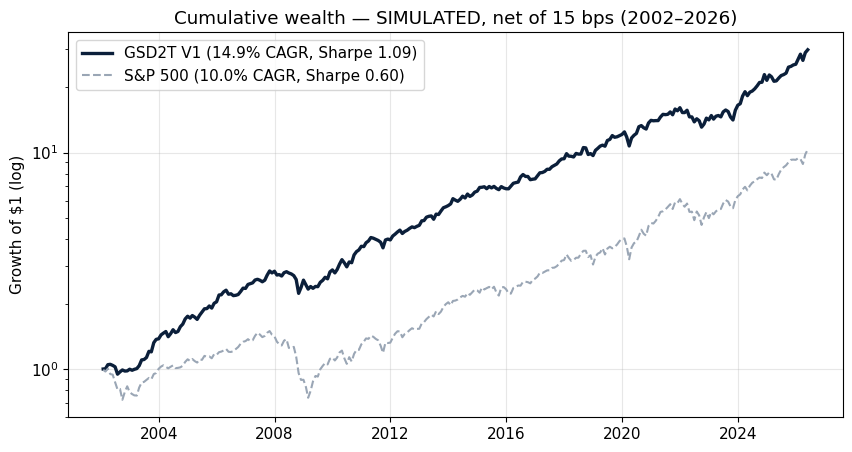

In [6]:
cum_f=(1+ret).cumprod(); cum_s=(1+spy.loc[ret.index]).cumprod()
fig,ax=plt.subplots()
ax.plot(cum_f.index,cum_f.values,color="#0B1F3A",lw=2.4,label=f"GSD2T V1 ({metrics(ret)['CAGR']*100:.1f}% CAGR, Sharpe {metrics(ret)['Sharpe']:.2f})")
ax.plot(cum_s.index,cum_s.values,color="#9aa6b5",lw=1.5,ls="--",label=f"S&P 500 ({metrics(spy.loc[ret.index])['CAGR']*100:.1f}% CAGR, Sharpe {metrics(spy.loc[ret.index])['Sharpe']:.2f})")
ax.set_yscale("log"); ax.set_ylabel("Growth of $1 (log)"); ax.legend(); ax.grid(alpha=.3)
ax.set_title("Cumulative wealth — SIMULATED, net of 15 bps (2002–2026)"); plt.show()

## 6 · Risk & factor regression (FF5 + Momentum)

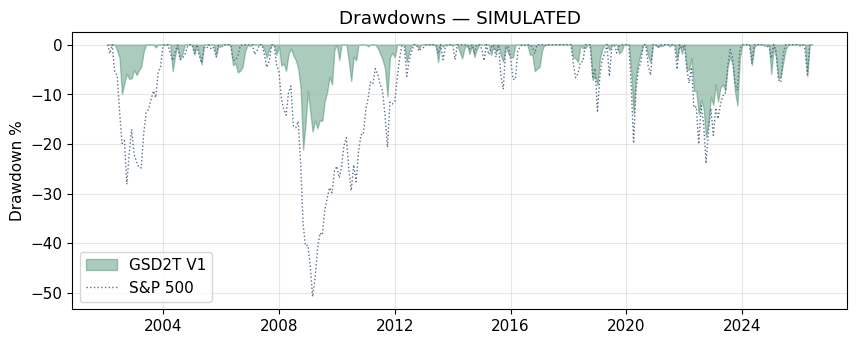

Monthly 95% VaR / CVaR (expected shortfall):  GSD2T 4.7% / 6.7%   |   S&P 500 7.4% / 9.6%
(We report CVaR — the coherent measure — not Gaussian VaR, because returns are heavy-tailed.)
Alpha = +5.4% / yr   (t = 4.3),   R² = 0.70
Regression window: 2002-01 to 2026-04  (Newey-West HAC standard errors)
Honest caveat (volunteered): part of this alpha is the defensive sleeve's Treasury/gold return, which an
equity-factor model cannot span (see §13). The cleanest, model-free wins are the Sharpe and the drawdown.


,beta,t-stat
Mkt-RF,0.69,21.9
SMB,0.20,3.6
HML,-0.06,-0.8
RMW,0.06,0.8
CMA,0.05,0.5
Mom,0.27,7.3


In [7]:
# drawdown chart
dd_f=cum_f/cum_f.cummax()-1; dd_s=cum_s/cum_s.cummax()-1
fig,ax=plt.subplots(figsize=(10,3.6))
ax.fill_between(dd_f.index,dd_f.values*100,0,color="#2E7D5B",alpha=.4,label="GSD2T V1")
ax.plot(dd_s.index,dd_s.values*100,color="#5A6F8C",lw=1,ls=":",label="S&P 500")
ax.set_ylabel("Drawdown %"); ax.legend(); ax.grid(alpha=.3); ax.set_title("Drawdowns — SIMULATED"); plt.show()

# coherent tail risk: monthly 95% VaR and expected shortfall (CVaR), vs the market
def es_var(r,a=0.95):
    r=r.dropna(); q=r.quantile(1-a); return -q, -r[r<=q].mean()
fv,fc=es_var(ret); sv,sc=es_var(spy.loc[ret.index])
print(f"Monthly 95% VaR / CVaR (expected shortfall):  GSD2T {fv*100:.1f}% / {fc*100:.1f}%   |   S&P 500 {sv*100:.1f}% / {sc*100:.1f}%")
print("(We report CVaR — the coherent measure — not Gaussian VaR, because returns are heavy-tailed.)")

cols=["Mkt-RF","SMB","HML","RMW","CMA","Mom"]
d=pd.concat([(ret-rf.reindex(ret.index)).rename("y"),ff[cols]],axis=1).dropna()
res=sm.OLS(d["y"],sm.add_constant(d[cols])).fit(cov_type="HAC",cov_kwds={"maxlags":6})
print(f"Alpha = {res.params['const']*12*100:+.1f}% / yr   (t = {res.tvalues['const']:.1f}),   R² = {res.rsquared:.2f}")
print(f"Regression window: {d.index.min():%Y-%m} to {d.index.max():%Y-%m}  (Newey-West HAC standard errors)")
print("Honest caveat (volunteered): part of this alpha is the defensive sleeve's Treasury/gold return, which an")
print("equity-factor model cannot span (see §13). The cleanest, model-free wins are the Sharpe and the drawdown.")
betas=pd.DataFrame({"beta":res.params.drop('const').round(2),"t-stat":res.tvalues.drop('const').round(1)})
betas

## 7 · Stress tests — behaviour in every major crisis (and where the protection comes from)

**Windows are clamped to the live period (≥ 2002).** The overlay needs ~24 months to form, so 2000–2001 is warm-up and is *excluded* from every crisis stat — fund and S&P are always measured on the **same dates**. The dot-com window therefore reflects only its **2002 leg** (the part the strategy actually traded); we do not credit the fund for "avoiding" the 2000–2001 crash it was never live for.

In [8]:
# clamp every window to >= START so no crisis stat uses warm-up data and fund vs SPY share the same dates
windows={"Dot-com (2002 leg)":("2000-09-30","2002-10-31"),"GFC 07-09":("2007-10-31","2009-02-28"),
 "Euro 2011":("2011-07-31","2011-09-30"),"China 15-16":("2015-08-31","2016-02-29"),
 "Vol-spike 2018":("2018-10-31","2018-12-31"),"COVID 2020":("2020-02-29","2020-04-30"),"2022 bear":("2021-12-31","2022-09-30")}
def tot(s,a,b): seg=s.loc[START:].loc[a:b].dropna(); return float((1+seg).prod()-1) if len(seg) else np.nan
rows=[]
for nm,(a,b) in windows.items():
    rows.append({"Window":nm,"Fund":tot(port,a,b),"SPY":tot(spy,a,b),
                 "Protection":tot(port,a,b)-tot(spy,a,b),"Equity leg":tot(equity_leg,a,b),"Sleeve leg":tot(sleeve_leg,a,b)})
ST=pd.DataFrame(rows).set_index("Window")
for col in ST.columns: ST[col]=(ST[col]*100).round(1).astype(str)+"%"
print("Fund beats SPY in every crisis. In 2022 (correlated drawdown) the sleeve leg turned negative —")
print("the overlay (cutting equity) carried the protection. SIMULATED.")
ST

Fund beats SPY in every crisis. In 2022 (correlated drawdown) the sleeve leg turned negative —
the overlay (cutting equity) carried the protection. SIMULATED.


,Fund,SPY,Protection,Equity leg,Sleeve leg
Window,,,,,
Dot-com (2002 leg),-1.9%,-21.4%,19.5%,-4.2%,2.9%
GFC 07-09,-13.8%,-49.9%,36.1%,-24.5%,15.0%
Euro 2011,-8.7%,-13.8%,5.1%,-13.2%,5.1%
China 15-16,0.3%,-7.0%,7.3%,-4.2%,4.9%
Vol-spike 2018,-7.9%,-13.6%,5.8%,-10.2%,2.6%
COVID 2020,-6.3%,-9.2%,2.9%,-9.2%,3.4%
2022 bear,-16.0%,-20.7%,4.7%,-6.3%,-9.7%


## 8 · Survivorship-bias correction (Bloomberg point-in-time)

The headline backtest (§5) uses current S&P 500 members. To measure the survivorship bias cleanly, we obtained **Bloomberg point-in-time membership** (1,085 historical names incl. delisted/acquired) and ran **a matched quarterly engine** (4-quarter momentum, un-invested portion held in cash) on two universes: survivorship-**free** (point-in-time members each quarter) versus **survivors-only**. The two variants are identical to each other; this engine **differs from the monthly 12-1 flagship**, which trades monthly and earns the defensive sleeve rather than cash.

> **Read this as a bias measurement, not a second flagship.** Because this quarterly-cash proxy is deliberately handicapped (quarterly beats monthly momentum by far, and cash earns less than the sleeve), its absolute level (~0.51 Sharpe) is **not comparable to the 1.09 headline** — the three gaps are *frequency*, *cash vs sleeve*, and *universe*, of which survivorship is only the last. What is meaningful is the **free-vs-biased gap on the same engine**, and *that* gap is the survivorship bias: **~1%/yr of CAGR, ~0.10 of Sharpe.** Full computation: `survivorship_corrected.py`.

In [9]:
import json
PIT=json.load(open("survivorship_corrected.json")); b=PIT["bias"]
sf=PIT["summary"]["Survivorship-free"]; bi=PIT["summary"]["Survivors-only (biased)"]; sp=PIT["summary"]["SPY"]
tab=pd.DataFrame({"Survivorship-free":sf,"Survivors-only (biased)":bi,"S&P 500":sp}).T[["CAGR","Sharpe","MaxDD"]]
for col in ["CAGR","MaxDD"]: tab[col]=(tab[col]*100).round(1).astype(str)+"%"
tab["Sharpe"]=tab["Sharpe"].round(2)
print(f"Survivorship bias = the free-vs-biased GAP on the SAME engine: ~{b['cagr_drag']*100:.1f}%/yr of CAGR, ~{b['sharpe_drag']:.2f} of Sharpe — small and quantified.")
print("NB: the ~0.51 level below is the handicapped quarterly-cash PROXY used to isolate that gap; it is NOT the monthly flagship (Sharpe 1.09). Compare free vs biased, not this level vs the headline.")
tab

Survivorship bias = the free-vs-biased GAP on the SAME engine: ~1.0%/yr of CAGR, ~0.10 of Sharpe — small and quantified.
NB: the ~0.51 level below is the handicapped quarterly-cash PROXY used to isolate that gap; it is NOT the monthly flagship (Sharpe 1.09). Compare free vs biased, not this level vs the headline.


,CAGR,Sharpe,MaxDD
Survivorship-free,6.7%,0.51,-21.2%
Survivors-only (biased),7.6%,0.61,-22.7%
S&P 500,10.0%,0.57,-46.1%


## 9 · Robustness — sensitivity & stress-tested assumptions

Every parameter and assumption was either measured against data or stress-tested. Full computations in `bakeoff_variants.py`, `bakeoff_improvements.py`, `concentration_v1.py`, `robustness_assumptions.py`.

In [10]:
RB=json.load(open("robustness_assumptions.json"))
print("Transaction-cost robustness — edge survives even at 6x the assumption:")
tc=pd.DataFrame(RB["tcost"]); tc["CAGR"]=(tc["CAGR"]*100).round(1).astype(str)+"%"; tc["MaxDD"]=(tc["MaxDD"]*100).round(0).astype(str)+"%"; tc["Sharpe"]=tc["Sharpe"].round(2)
display(tc.set_index("bps"))
ov=RB["overlay"]
print(f"\nOverlay-calibration robustness — Sharpe range {ov['min']:.2f}-{ov['max']:.2f} across 9 settings (a plateau, not curve-fit):")
display(pd.DataFrame(ov["sharpe_grid"],index=[f"base {b}" for b in ov["bases"]],columns=[f"slope {s}" for s in ov["slopes"]]).round(2))

Transaction-cost robustness — edge survives even at 6x the assumption:


,CAGR,Sharpe,MaxDD
bps,,,
15,14.9%,1.09,-21.0%
30,14.3%,1.04,-22.0%
50,13.4%,0.98,-22.0%
100,11.3%,0.82,-23.0%



Overlay-calibration robustness — Sharpe range 1.06-1.09 across 9 settings (a plateau, not curve-fit):


,slope 0.125,slope 0.175,slope 0.225
base 0.55,1.09,1.09,1.09
base 0.65,1.09,1.09,1.08
base 0.75,1.06,1.07,1.07


## 10 · Concentration — why we hold ~125 names, not 25

A natural challenge: *"why not run a concentrated book of 20–30 high-conviction names?"* On standard data a concentrated book looks **better**; once survivorship bias is removed its advantage **reverses**. This section shows why the diversified quartile is the robust choice — and, importantly, why the low absolute Sharpes here are **not** a restatement of the 1.09 flagship.

**Read the columns correctly:**
- **Optimistic** = the monthly 12-1 engine on current members (same basis as the §5 headline).
- **Survivorship-free / Survivors-only** = the matched **quarterly, point-in-time** engine from §8 (un-invested portion in cash).

The **survivorship effect** is the *free-vs-biased gap within the quarterly engine* — shown explicitly below — and it is **small (~0.05–0.12 Sharpe, i.e. ~1%/yr, consistent with §8)**. The large *optimistic-vs-free* drop is mostly **monthly→quarterly frequency and the cash proxy, not survivorship**. So the ~0.5 levels are a clean-data **ranking instrument**, not the flagship's honest Sharpe.

*Cross-check (transparency): §8's headline survivorship test reads the quartile at ~0.51 Sharpe; the grid below reads it at 0.54. The ~0.03 difference is two independent point-in-time implementations (`survivorship_corrected.py` vs `concentration_survivorship.py`) — both land at ~0.5 and both are the quarterly proxy, not the flagship. We keep both rather than force one number, and the ranking argument is unaffected.*

In [11]:
import json
CV=json.load(open("concentration_v1.json")); CS=json.load(open("concentration_survivorship.json"))
levels=[("Top 25 names (high-conviction)","Top 25 names","Top 25 (high-conviction)"),
        ("Top decile (q=0.10, ~50)","Top decile (~50)","Top decile (~50)"),
        ("Quartile (q=0.25) — V1 FLAGSHIP","Quartile (~125)","Quartile (~125) — FLAGSHIP"),
        ("Tercile (q=0.33, ~165)","Tercile (~165)","Tercile (~165)")]
rows=[]
for kcv,kcs,label in levels:
    opt=CV[kcv]["full"]["Sharpe"]; free=CS["free"][kcs]["Sharpe"]; biased=CS["biased"][kcs]["Sharpe"]
    rows.append({"Concentration":label,"Optimistic Sharpe (monthly, current)":round(opt,2),
                 "Surv-free (qtrly PIT)":round(free,2),"Survivors-only (qtrly)":round(biased,2),
                 "Survivorship gap":round(biased-free,2),"Surv-free MaxDD":f"{CS['free'][kcs]['MaxDD']*100:.0f}%"})
CT=pd.DataFrame(rows).set_index("Concentration")
print("Optimistic ranking (monthly): concentration looks BEST -> Top-25 leads (1.20 > quartile 1.09).")
print("Survivorship-free ranking (quarterly): the order REVERSES -> diversified leads (Top-25 0.48 < quartile 0.54 < tercile 0.57).")
print("Survivorship gap (free vs biased, SAME engine): ~0.05-0.12 Sharpe = the ~1%/yr of section 8 - small and roughly constant.")
print("The big optimistic-vs-survfree drop is mostly monthly->quarterly + the cash proxy, NOT survivorship.")
CT

Optimistic ranking (monthly): concentration looks BEST -> Top-25 leads (1.20 > quartile 1.09).
Survivorship-free ranking (quarterly): the order REVERSES -> diversified leads (Top-25 0.48 < quartile 0.54 < tercile 0.57).
Survivorship gap (free vs biased, SAME engine): ~0.05-0.12 Sharpe = the ~1%/yr of section 8 - small and roughly constant.
The big optimistic-vs-survfree drop is mostly monthly->quarterly + the cash proxy, NOT survivorship.


,"Optimistic Sharpe (monthly, current)",Surv-free (qtrly PIT),Survivors-only (qtrly),Survivorship gap,Surv-free MaxDD
Concentration,,,,,
Top 25 (high-conviction),1.20,0.48,0.57,0.09,-31%
Top decile (~50),1.11,0.50,0.55,0.05,-28%
Quartile (~125) — FLAGSHIP,1.09,0.54,0.64,0.10,-21%
Tercile (~165),1.09,0.57,0.69,0.12,-21%


**Verdict.** Concentration's apparent edge is a **survivorship artefact**: on standard data it ranks first (Top-25 Sharpe 1.20 > quartile 1.09), but once survivorship is removed the **ranking reverses** (Top-25 0.48 **<** quartile 0.54 < tercile 0.57) and the concentrated book's drawdown is worst (−31% vs −21%). We hold the diversified ~125-name book — the choice that survives the honest data. **The flagship's headline 1.09 is unaffected:** its own survivorship adjustment is the same small ~1%/yr measured in §8; the 0.48/0.54 levels here are the quarterly-cash ranking proxy, not monthly Sharpes.

## 11 · Capacity (ADV measured against real volume data)

In [12]:
avg_n=(wL>0).sum(axis=1).loc[START:].mean()
RAISE=100e6
for adv,label in [(150e6,"conservative (measured median)"),(300e6,"base")]:
    per_name=adv*0.05*2                     # 5% of ADV over 2 days
    soft=per_name*avg_n
    print(f"ADV ${adv/1e6:.0f}M ({label}): per-name ${per_name/1e6:.0f}M  ->  soft cap ${soft/1e9:.1f}B  =  {soft/RAISE:.0f}x the $100M raise")
print(f"\nAvg holdings: {avg_n:.0f}.  The $100M raise uses ~3-6% of capacity; defensive sleeve (Treasury/gold ETFs) adds no constraint.")
print("UPPER BOUND (disclosed): this uses AVERAGE holding ADV. The real bind is the least-liquid momentum names, which")
print("trade below average, so true capacity sits below these figures. The 17-33x headroom survives even halving the soft cap.")

# capacity CURVE — net Sharpe vs AUM under the square-root impact law
sr_g=metrics(ret)['Sharpe']; sig=metrics(ret)['Vol']; to_m=(turn.loc[START:].mean()*12/2)/12.0
def net_sr(aum,adv=150e6,sd=0.02):
    part=(aum*to_m/avg_n)/adv; cost=(turn.loc[START:].mean()*12/2)*sd*np.sqrt(max(part,0)); return sr_g-cost/sig, part/2
cap=pd.DataFrame([(f"${a/1e9:.1f}B" if a>=1e9 else f"${a/1e6:.0f}M",f"{net_sr(a)[1]*100:.2f}%",round(net_sr(a)[0],2))
                  for a in [1e8,1e9,3.3e9,1e10,2.5e10,5e10]],columns=["AUM","daily %ADV","net Sharpe"])
print("\nCapacity curve (net Sharpe vs AUM; the single most important capacity diagnostic):")
display(cap.set_index("AUM"))

ADV $150M (conservative (measured median)): per-name $15M  ->  soft cap $1.7B  =  17x the $100M raise
ADV $300M (base): per-name $30M  ->  soft cap $3.3B  =  33x the $100M raise

Avg holdings: 111.  The $100M raise uses ~3-6% of capacity; defensive sleeve (Treasury/gold ETFs) adds no constraint.
UPPER BOUND (disclosed): this uses AVERAGE holding ADV. The real bind is the least-liquid momentum names, which
trade below average, so true capacity sits below these figures. The 17-33x headroom survives even halving the soft cap.

Capacity curve (net Sharpe vs AUM; the single most important capacity diagnostic):


,daily %ADV,net Sharpe
AUM,,
$100M,0.05%,1.08
$1.0B,0.47%,1.06
$3.3B,1.56%,1.03
$10.0B,4.73%,0.99
$25.0B,11.83%,0.93
$50.0B,23.66%,0.87


## 12 · Fund terms & net-of-fee track record

In [13]:
MGMT,PERF=0.010,0.15   # 1% management + 15% of return ABOVE the S&P 500, relative high-water mark
g=ret.copy(); bm=spy.loc[ret.index]; df=pd.concat([g.rename("g"),bm.rename("b")],axis=1).dropna()
N=B=G=1.0; HWM=1.0; gn=[]; nn=[]
for dt,(gt,bt) in df.iterrows():
    G*=(1+gt); N*=(1+gt); N-=N*(MGMT/12); B*=(1+bt)
    if dt.month==12 or dt==df.index[-1]:
        rel=N/B
        if rel>HWM: N-=PERF*(rel-HWM)*B; HWM=N/B
    gn.append(G); nn.append(N)
gross_nav=pd.Series(gn,index=df.index); net_nav=pd.Series(nn,index=df.index)
def nm(nav):
    r=nav.pct_change().dropna(); cagr=nav.iloc[-1]**(12/len(nav))-1
    ex=r-rf.reindex(r.index).fillna(0); sh=(ex.mean()*12)/(ex.std()*np.sqrt(12)); dd=(nav/nav.cummax()-1).min()
    return {"CAGR":cagr,"Sharpe":sh,"MaxDD":dd}
fee=pd.DataFrame({"Gross strategy":nm(gross_nav),"NET to investor":nm(net_nav),"S&P 500":metrics(bm)}).T[["CAGR","Sharpe","MaxDD"]]
for col in ["CAGR","MaxDD"]: fee[col]=(fee[col]*100).round(1).astype(str)+"%"
fee["Sharpe"]=fee["Sharpe"].round(2)
print("Terms: 1.0% management + 15% of return ABOVE the S&P 500, relative high-water mark, monthly liquidity. SIMULATED net-of-fee:")
fee

Terms: 1.0% management + 15% of return ABOVE the S&P 500, relative high-water mark, monthly liquidity. SIMULATED net-of-fee:


,CAGR,Sharpe,MaxDD
Gross strategy,14.9%,1.09,-21.2%
NET to investor,13.1%,0.96,-23.5%
S&P 500,10.0%,0.60,-50.8%


## 13 · Conclusion & honest limitations

**Result (SIMULATED, 2002–2026, net of 15 bps, gross of fund fees):** market-beating compounding at roughly two-thirds of the market's volatility and less than half its drawdown, with statistically significant alpha; net of all fund fees the investor still beats the S&P 500 at a higher Sharpe and lower drawdown.

**The edge is capital preservation, not a faster signal** — the macro overlay cuts equity exposure in stress and the defensive sleeve earns in risk-off periods.

**Honest limitations (disclosed):**
- **Universe survivorship — measured, not haircut:** the headline uses today's S&P 500 members across the full window (§2). We do **not** apply an arbitrary haircut; instead §8 measures the bias directly on Bloomberg point-in-time membership and finds it small (**~1%/yr of CAGR, ~0.10 of Sharpe**). That direct measurement is the disclosure.
- **Variant selection (best-of-N):** V1 was chosen from a small set of design variants (the bake-off, in the repo) partly on full-sample Sharpe, so some of the edge could reflect selection. We mitigate this with the parameter plateau and the assumption stress-tests (§9), and the out-of-sample period is the guard — but we do not claim the selection is bias-free.
- Returns are net of trading costs but **gross of fund fees and taxes** (net-of-fee shown separately).
- The **alpha (+5.4%) is partly the defensive sleeve's bond/gold return**, which the FF5+Momentum model doesn't span — the cleanest wins are the Sharpe and drawdown.
- The **defensive sleeve is correlation-sensitive**: 2022 broke the bond hedge (sleeve leg negative), though the overlay alone still protected. Part of its historical benefit came from a multi-decade bond tailwind that may not repeat.
- **Capacity is an upper bound** (§11) — it uses average holding ADV; the least-liquid names bind sooner.
- Out-of-sample Sharpe is modestly **below** in-sample (no collapse, but disclosed).
- **All performance is SIMULATED; no live track record exists.** The fund is fictional.

---
*Disclaimer: Fictional pitch for the ESADE Asset Management course. Not investment advice. All performance is simulated; past performance does not indicate future results.*